In [66]:
import pandas as pd
import rasterio as rio
from rasterio.plot import show
import xarray as xr
import netCDF4 as nc
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd

ImportError: DLL load failed while importing _netCDF4: The specified procedure could not be found.

## Read underway CSV

In [11]:
data = pd.read_csv("merged_data/merged.csv", skiprows=21, header=0)

In [58]:
data = data.rename(columns={"latitude (decimal degrees)":"lat",
                           "longitude (decimal degress)":"lon",
                           "relative_wind_speed (knots)":"windspeed",
                           "sea_surface_temperature (degC)":"seatemp",
                           "air_temperature (degC)":"airtemp",
                           "salinity (psu)":"salinity",
                           "PAR (umol/m2/s)":"par"})

In [63]:
dataset = xr.Dataset(data,coords=["time","lat","lon"])

ValueError: variables {'lat', 'time'} are found in both data_vars and coords

## Read in bathymetry file

In [44]:
bathy = rio.open("../../gis/bathymetry_grids/bathy_KG_0005d.tif")

In [52]:
bed = xr.open_dataset("../CTD/plot_transects/BedMachine-v5_crop.nc")

ImportError: DLL load failed while importing _netCDF4: The specified procedure could not be found.

In [46]:
bathy.crs

CRS.from_wkt('COMPD_CS["WGS 84 + EGM96 height",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]],VERT_CS["EGM96 height",VERT_DATUM["EGM96 geoid",2005,AUTHORITY["EPSG","5171"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related height",UP],AUTHORITY["EPSG","5773"]],AUTHORITY["EPSG","9707"]]')

## Cruise track

In [29]:
proj = ccrs.PlateCarree()

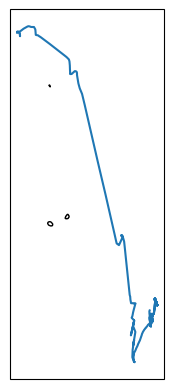

In [57]:
lons,lats = data['longitude (decimal degrees)'], data['latitude (decimal degrees)']
#lats = data['latitude (decimal degrees)']

ax = plt.axes(projection=ccrs.PlateCarree())
ax.plot(lats,lons) # ccrs=proj
ax.coastlines()
plt.show()

In [14]:
# Coloured by salinity

# cbar = plt.cbar("RdBu")

AttributeError: module 'matplotlib' has no attribute 'cbar'

In [ ]:
# Coloured by sea surface temperature

cbar = 

## Read CTD deployment locations

In [37]:
CTD_locations = gpd.read_file("../../gis/deployments/CTD.shp")

In [40]:
CTD_locations = CTD_locations.set_crs("EPSG:4326")

In [ ]:
# Rename fields for easier indexing
CTD_locations.rename(
    columns={' CTD cast number(Built In - String)': 'CTD_cast',
             ' Latitude (dd)(sd_gnss_kongsberg_seapath_320_port1_ingga - latitude)': 'lat',
             ' Longitude (dd)(sd_gnss_kongsberg_seapath_320_port1_ingga - longitude)': 'lon',
             ' Event action(Built In - String)': 'action'})

# Convert time column to parseable datetime
CTD_locations["Time"] = pd.to_datetime(CTD_locations["Time"], format="%H:%M:%S %d/%m/%Y")

# Keep just inWater entries (one per cast)
CTD_locations = CTD_locations[(CTD_locations['Time'] >= pd.Timestamp(start_time)) &
    (CTD_locations['Time'] <= pd.Timestamp(end_time)) &
    (CTD_locations['action'] == 'inWater')]

In [ ]:
# Plot cast locations


## First basic plots

In [ ]:
plt.plot(x=[''],y=data[''])

## CTD section met conditions